# Eksperimen Model: KNN (K-Nearest Neighbors)
Algoritma ini sangat sederhana dan cepat. Sama seperti SVM, KNN juga menghitung jarak (Euclidean), sehingga **wajib** menggunakan StandardScaler.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Library KNN siap!')

Library KNN siap!


### 1. Memuat Data & Preprocessing

In [2]:
X = np.load('X_features.npy')
y = np.load('y_labels.npy')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'models/scaler_knn.pkl')

['models/scaler_knn.pkl']

### 2. Melatih Model KNN

In [3]:
# Mencari 5 tetangga terdekat
model_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
model_knn.fit(X_train_scaled, y_train)
print('Proses pelatihan KNN selesai!')

Proses pelatihan KNN selesai!


### 3. Evaluasi & Visualisasi


🎯 AKURASI KNN: 56.67%

              precision    recall  f1-score   support

       horas       0.53      0.60      0.57        90
  sampurasun       0.43      0.54      0.48        90
adilkatalino       0.40      0.63      0.49        90
      wawawa       0.88      0.59      0.71        90
   kulanuwun       0.61      0.57      0.59        90
       tabea       0.75      0.59      0.66        90
     peuhaba       0.70      0.44      0.54        90

    accuracy                           0.57       630
   macro avg       0.62      0.57      0.58       630
weighted avg       0.62      0.57      0.58       630



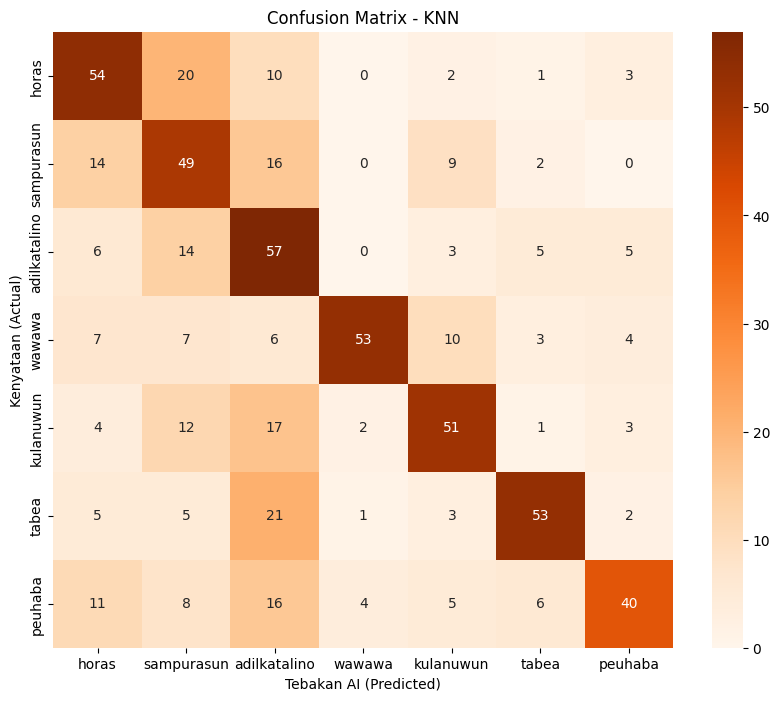

In [5]:
y_pred = model_knn.predict(X_test_scaled)
akurasi = accuracy_score(y_test, y_pred)
print(f'\n🎯 AKURASI KNN: {akurasi * 100:.2f}%\n')

classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - KNN')
plt.xlabel('Tebakan AI (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.show()

### 4. Simpan Model

In [ ]:
joblib.dump(model_knn, 'models/knn_model.pkl')
print('Model KNN berhasil disimpan!')